In [1]:
import geopandas as gpd
from eoflow.rivers import build_river_network_graph, calculate_graph_length_meters
import matplotlib.pyplot as plt
import networkx as nx

In [2]:
river_gdf = gpd.read_file("hydro_rivers.gdf")

In [3]:
river_gdf

,HYRIV_ID,NEXT_DOWN,MAIN_RIV,LENGTH_KM,DIST_DN_KM,DIST_UP_KM,CATCH_SKM,UPLAND_SKM,ENDORHEIC,DIS_AV_CMS,ORD_STRA,ORD_CLAS,ORD_FLOW,HYBAS_L12,Shape_Leng,geometry
0,20350404,20350777,20346222,0.69,36.099998,3.300000,3.790000,3.800000,0,0.115,1,4,7,2.120407e+09,0.006250,"LINESTRING (-3.83542 50.926, -3.83542 50.92292)"
1,20350405,20350777,20346222,4.47,36.200001,6.800000,12.310000,12.300000,0,0.369,1,3,7,2.120407e+09,0.053242,"LINESTRING (-3.83233 50.926, -3.83542 50.92292)"
2,20350521,20350204,20346222,3.98,25.900000,8.500000,9.070000,26.400000,0,0.814,2,2,7,2.120407e+09,0.051011,"LINESTRING (-3.92756 50.92292, -3.91458 50.922..."
3,20350522,20351000,20356945,2.95,33.500000,46.700001,7.440000,431.000000,0,11.779,3,1,5,2.121125e+09,0.028452,"LINESTRING (-3.49792 50.926, -3.49792 50.91875)"
4,20350649,20350888,20346222,2.84,45.000000,5.000000,8.520000,8.500000,0,0.251,1,3,7,2.120407e+09,0.028957,"LINESTRING (-3.73125 50.926, -3.73125 50.91875..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
253,20360784,20360663,20360350,1.37,13.400000,4.300000,6.420000,6.400000,0,0.186,1,3,7,2.120049e+09,0.014731,"LINESTRING (-3.6615 50.526, -3.65625 50.53125)"
254,20360873,20361315,20365195,7.21,34.400002,23.900000,17.059999,138.399994,0,4.326,3,1,6,2.121128e+09,0.084640,"MULTILINESTRING ((-3.87292 50.53958, -3.86875 ..."
255,20360999,20361624,20365195,2.38,30.799999,5.600000,7.780000,7.800000,0,0.233,1,2,7,2.121129e+09,0.024791,"LINESTRING (-3.7625 50.53333, -3.75625 50.5270..."
256,20361001,20360447,20360350,2.40,8.200000,9.200000,4.640000,32.099998,0,0.906,2,2,7,2.120049e+09,0.022559,"LINESTRING (-3.59375 50.526, -3.59375 50.53542)"


In [4]:
graph = build_river_network_graph(river_gdf)

In [5]:
graph

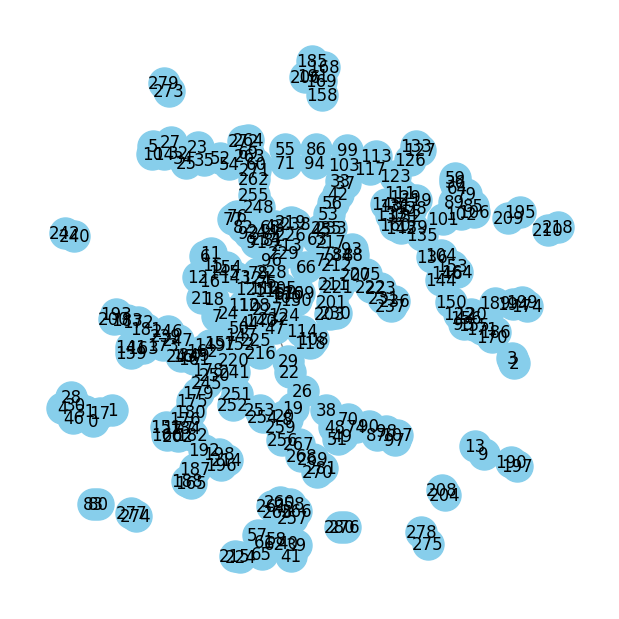

In [6]:
# Draw
plt.figure(figsize=(6, 6))
nx.draw(graph, with_labels=True, node_color='skyblue', edge_color='gray', node_size=500)
plt.show()

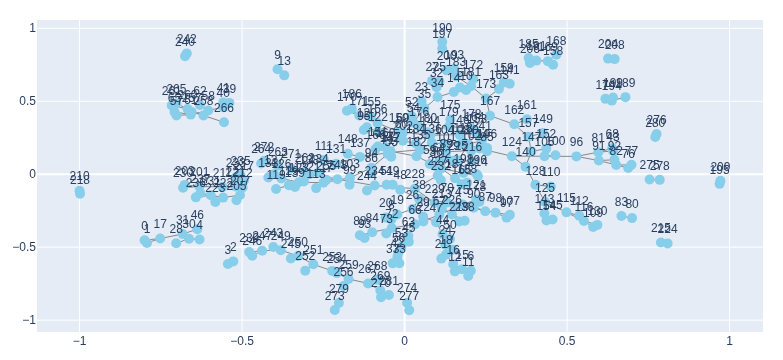

In [7]:
import plotly.graph_objects as go

pos = nx.spring_layout(graph)  # layout

# Edge traces
edge_x = []
edge_y = []
for edge in graph.edges():
    x0, y0 = pos[edge[0]]
    x1, y1 = pos[edge[1]]
    edge_x.extend([x0, x1, None])
    edge_y.extend([y0, y1, None])

edge_trace = go.Scatter(x=edge_x, y=edge_y,
                        line=dict(width=1, color='#888'),
                        hoverinfo='none',
                        mode='lines')

# Node traces
node_x = []
node_y = []
for node in graph.nodes():
    x, y = pos[node]
    node_x.append(x)
    node_y.append(y)

node_trace = go.Scatter(x=node_x, y=node_y,
                        mode='markers+text',
                        hoverinfo='text',
                        marker=dict(color='skyblue', size=10),
                        text=[str(n) for n in graph.nodes()],
                        textposition="top center")

# Create figure
fig = go.Figure(data=[edge_trace, node_trace],
                layout=go.Layout(showlegend=False, margin=dict(t=20, b=20, l=20, r=20)))
fig.show()